# Diagnostics, visualization & serialization

Evaluate a fitted dtfit model: information criteria, residual-structure tests,
ready-made plots, opt-in logging, and round-trip serialization. (For plain
scalar metrics on arrays, use `sklearn.metrics` / `scipy.stats` directly.)

In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Fitting at extreme parameter trials can overflow exp() harmlessly; keep the
# guide output clean.
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)

In [2]:
from dtfit import fit_lsi

x = np.linspace(0, 4, 250)
y = 0.5 + 2.0 * np.exp(0.5 * x) + rng.normal(0, 0.2, x.size)
res = fit_lsi(x, y, "a0 + a1*exp(a2*x)", "x")

## `fit_report` - sample/param counts, RSS, RMSE, r^2, AIC/BIC, Durbin-Watson

In [3]:
from dtfit.diagnostics import fit_report

for k, v in fit_report(res, x, y).items():
    print(f"{k:14s}: {v}")

n             : 250
n_params      : 3
rss           : 10.297722057782973
rmse          : 0.2029553848291094
r2            : 0.9967939316388995
aic           : -791.3845516311394
bic           : -780.8201688775526
durbin_watson : 1.9154222014418871
params        : {'a0': 0.5363006809386689, 'a1': 1.9828259806182422, 'a2': 0.5010541705725822}
stderr        : {'a0': 0.07149670193675046, 'a1': 0.051743577173523035, 'a2': 0.005761962128013357}


## `residual_diagnostics` - residual structure (autocorrelation, normality)

In [4]:
from dtfit.diagnostics import residual_diagnostics

rd = residual_diagnostics(res, x, y)
print("Durbin-Watson :", round(rd["durbin_watson"], 3))
print("lag-1 autocorr:", round(rd["lag1_autocorr"], 3))
print("normality p   :", round(rd["normality_p"], 3))

Durbin-Watson : 1.915
lag-1 autocorr: 0.04
normality p   : 0.892


## Ready-made plots - `FitDisplay`, `ResidualsDisplay`

scikit-learn-style display objects with `from_predictions` / `from_estimator`
constructors (require matplotlib).

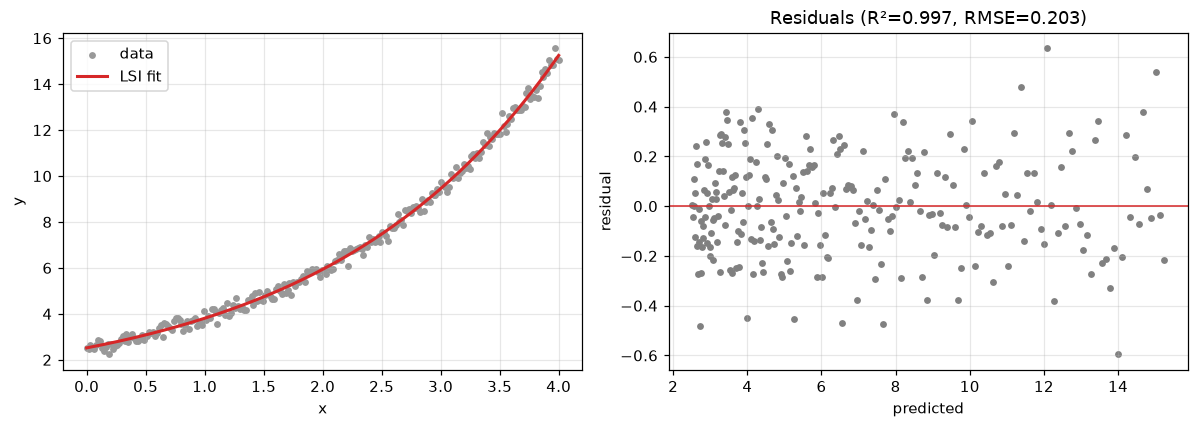

In [5]:
from dtfit.diagnostics import FitDisplay, ResidualsDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
FitDisplay.from_predictions(x, y, res.predict(x), ax=axes[0], estimator_name="LSI")
ResidualsDisplay.from_predictions(y, res.predict(x), ax=axes[1], estimator_name="LSI")
plt.tight_layout(); plt.show()

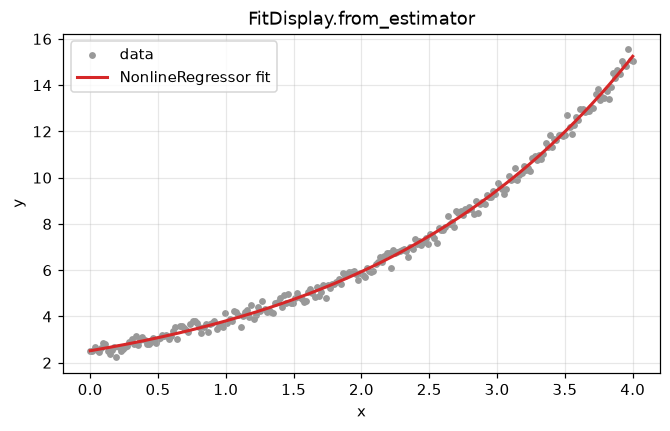

In [6]:
from dtfit import NonlineRegressor

reg = NonlineRegressor("a0 + a1*exp(a2*x)", "x").fit(x.reshape(-1, 1), y)
FitDisplay.from_estimator(reg, x.reshape(-1, 1), y)
plt.title("FitDisplay.from_estimator"); plt.show()

## Opt-in logging

dtfit logs through the standard `logging` module under the `"dtfit"` logger and
attaches only a `NullHandler` by default. `enable_logging(DEBUG)` surfaces the
fitting internals.

In [7]:
import logging
from dtfit import enable_logging

enable_logging(logging.DEBUG)
_ = fit_lsi(x, y, "a*exp(b*x)", "x")     # emits fitting detail
logging.getLogger("dtfit").handlers = [logging.NullHandler()]   # quiet again

dtfit DEBUG: LSI Legendre spectral order: 5


dtfit DEBUG: LSI fitted coefficients:


dtfit DEBUG: [2.37535277 0.46240435]


## Serialize a fit - `to_dict` / `from_dict`

Everything needed to rebuild the model (expression, names, coefficients,
covariance) round-trips through a JSON-friendly dict.

In [8]:
from dtfit import FittingResult

blob = res.to_dict()
print(blob)
restored = FittingResult.from_dict(blob)
print("round-trip params:", {k: round(v, 3) for k, v in restored.params.items()})

{'expr': 'a0 + a1*exp(a2*x)', 'var': 'x', 'names': ['a0', 'a1', 'a2'], 'coeffs': [0.5363006809386689, 1.9828259806182422, 0.5010541705725822], 'cov': [[0.005111778387832538, -0.0036285322836194776, 0.000395840337225544], [-0.003628532283619478, 0.0026773977787123344, -0.00029652078956429826], [0.0003958403372255441, -0.00029652078956429826, 3.320020756466021e-05]]}
round-trip params: {'a0': 0.536, 'a1': 1.983, 'a2': 0.501}
